In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from analysis_utils import (
    load_span, analyse_trades
)

BASE_DIR = Path.cwd() # use this for Jupyter notebook
print(f"Base directory set to: {BASE_DIR}")

Base directory set to: c:\Users\Wang0\Documents\UNSW\Honours Thesis\code


## Load Trade History
Generate a single dataframe from the signals and PnL parquet files, then split into strategy-specific dataframes.

In [ ]:
start_month = "2023-01"
end_month   = "2023-05"
file_path = BASE_DIR / "backtest_results"

all_trades = load_span(file_path, start_month, end_month, prefix="trades")

# Compute columns
# all_trades["pnl_norm"] = all_trades["pnl"] / all_trades["notional"]
all_trades["win"] = (all_trades["pnl"] > 0).astype(int)
print(f"Loaded {len(all_trades)} trades from {start_month} to {end_month}")
print(all_trades)
print(all_trades.shape)

strategy_trades = {
    strategy: trades.reset_index(drop=True)
    for strategy, trades in all_trades.groupby("strategy", sort=False)
}
strategy_list = ["short_straddle_hold", "short_straddle_1w", "long_call_calendar_30_60", "long_straddle_calendar_30_60"]
# to access individual strategy dataframe, use strategy_trades[strategy_list[0]] or strategy_trades["short_straddle_hold"]

Loaded 51564 trades from 2023-01 to 2023-05
      ticker           strategy  open_date close_date short_expiry  \
0        SPY  short_straddle_1w 2023-01-03 2023-01-09   2023-02-03   
1        QQQ  short_straddle_1w 2023-01-03 2023-01-09   2023-02-03   
2        SPX  short_straddle_1w 2023-01-03 2023-01-09   2023-02-02   
3       TSLA  short_straddle_1w 2023-01-03 2023-01-09   2023-02-03   
4       AAPL  short_straddle_1w 2023-01-03 2023-01-09   2023-02-03   
...      ...                ...        ...        ...          ...   
51559   BLNK  short_straddle_1w 2023-05-26 2023-05-31   2023-06-23   
51560    FDX  short_straddle_1w 2023-05-26 2023-05-31   2023-06-23   
51561    CPB  short_straddle_1w 2023-05-26 2023-05-31   2023-06-23   
51562    UAL  short_straddle_1w 2023-05-26 2023-05-31   2023-06-23   
51563   VALE  short_straddle_1w 2023-05-26 2023-05-31   2023-06-23   

      long_expiry  strike  entry_credit  entry_debit         pnl  ...  \
0             NaT   367.0     23.969999   

## Raw Analysis

PnL Summary:
count    12174.000000
mean        -1.312800
std         15.017210
min       -378.060913
25%         -0.123021
50%          0.392157
75%          0.740280
max          1.000000
Name: pnl_norm, dtype: float64

Additional Analysis:
Total PnL: -15982.03
Median PnL: 0.39
Number of positive trades: 8589
Number of negative trades: 3579
Max PnL: 1.00
Min PnL: -378.06


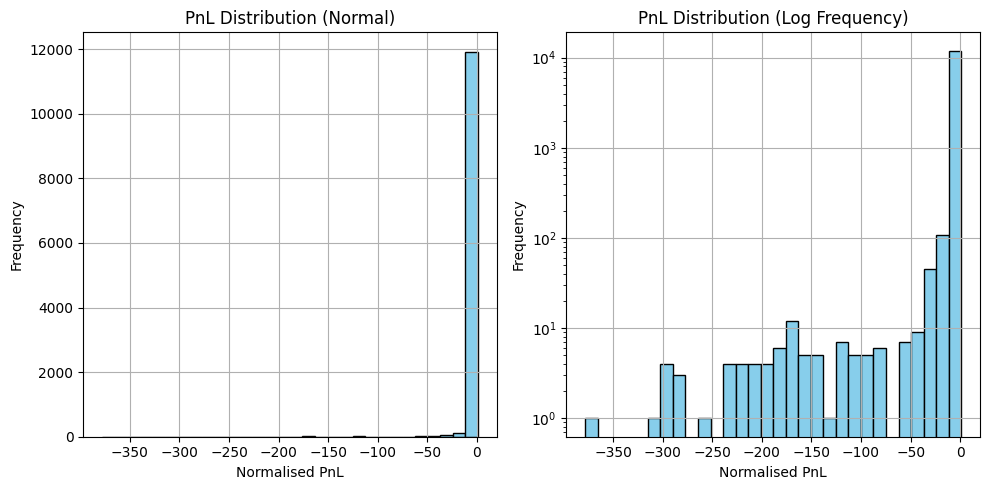

In [15]:
trades = strategy_dfs["short_straddle_hold"]
analyse_trades(trades, log=True)

## Filter Trades

PnL Summary:
count    625.000000
mean      -5.493206
std       33.099022
min     -300.519348
25%       -0.067157
50%        0.442623
75%        0.774611
max        1.000000
Name: pnl_norm, dtype: float64

Additional Analysis:
Total PnL: -3433.25
Median PnL: 0.44
Number of positive trades: 456
Number of negative trades: 169
Max PnL: 1.00
Min PnL: -300.52


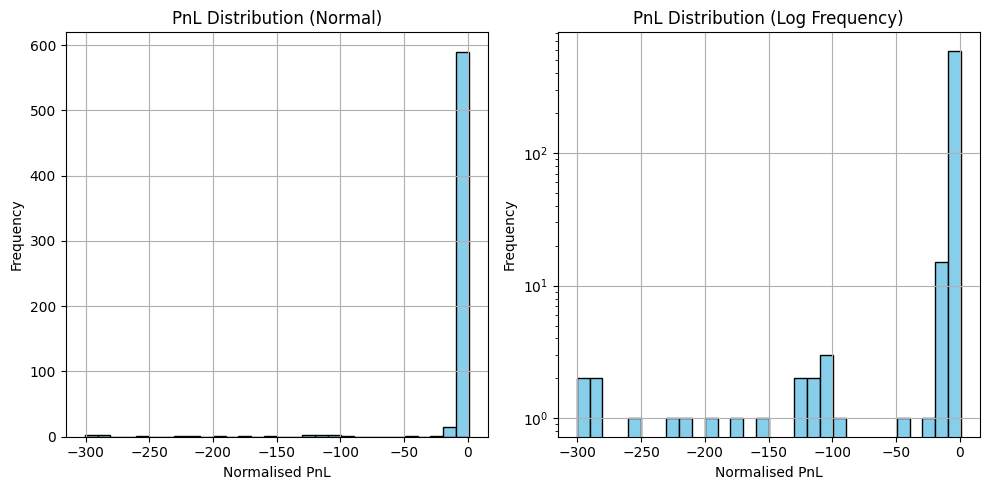

In [24]:
mask = (trades["ts45"] <= -0.004) & (trades["iv30_rv30"] >= 1.25)
filtered_trades = trades.loc[mask]
analyse_trades(filtered_trades, log=True)

## Average PnL for Different Tickers

In [25]:
# Calculate average PnL for each ticker
pnl_by_ticker = trades.groupby("ticker")["pnl_norm"].mean()
filtered_pnl_by_ticker = filtered_trades.groupby("ticker")["pnl_norm"].mean()

concat_df = pd.concat([pnl_by_ticker, filtered_pnl_by_ticker], axis=1)
concat_df.columns = ['All Trades', 'Filtered Trades']
concat_df = concat_df.sort_values(by='Filtered Trades', ascending=False)

print("Average PnL by Ticker:")
print(concat_df)

Average PnL by Ticker:
        All Trades  Filtered Trades
ticker                             
SNOW      0.219683         0.999515
PFE       0.646774         0.952937
BLNK      0.120102         0.903226
KO        0.631230         0.896259
BITO      0.875957         0.883331
...            ...              ...
UBER     -0.120592              NaN
UNG      -0.512405              NaN
VIX       0.425004              NaN
WULF      0.108589              NaN
WYNN      0.434600              NaN

[150 rows x 2 columns]


# Cross sectional checks

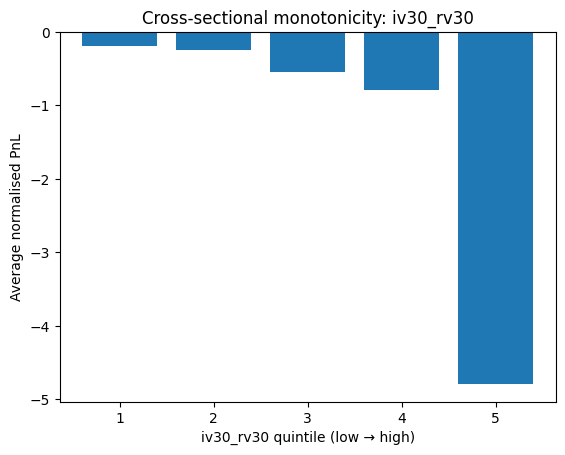

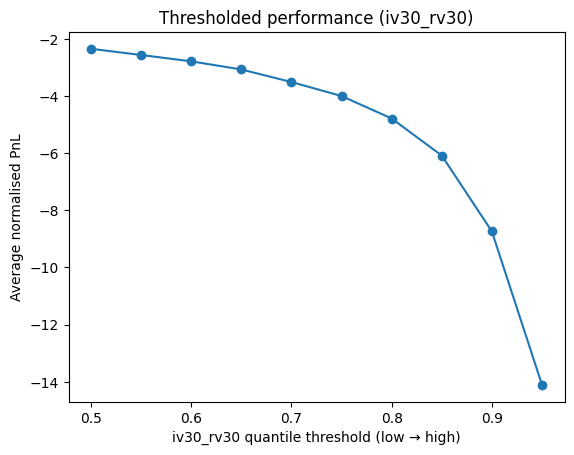

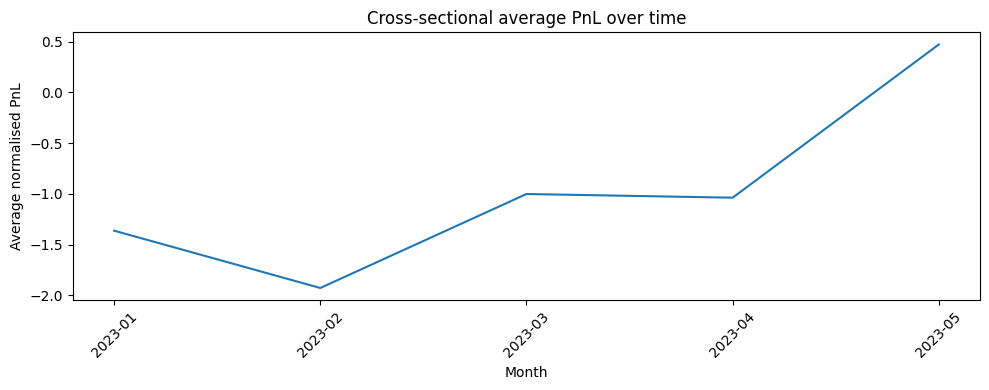

In [27]:
TARGET = "pnl_norm"
signal = "iv30_rv30"

trades["signal_quintile"] = pd.qcut(trades[signal], 5, labels=False) + 1
cs_quintile = (
    trades.groupby("signal_quintile")[TARGET]
    .mean()
    .reset_index()
)
plt.figure()
plt.bar(cs_quintile["signal_quintile"], cs_quintile[TARGET])
plt.xlabel("iv30_rv30 quintile (low → high)")
plt.ylabel("Average normalised PnL")
plt.title("Cross-sectional monotonicity: iv30_rv30")
plt.show()


# If I only trade strong signals, doeso performance improve?
thresholds = np.linspace(0.5, 0.95, 10)
threshold_results = []
for q in thresholds:
    cutoff = trades[signal].quantile(q)
    subset = trades[trades[signal] > cutoff]

    threshold_results.append({
        "quantile": q,
        "avg_pnl_norm": subset[TARGET].mean(),
        "win_rate": subset["win"].mean(),
        "n_trades": len(subset),
    })
threshold_df = pd.DataFrame(threshold_results)
plt.figure()
plt.plot(threshold_df["quantile"], threshold_df["avg_pnl_norm"], marker="o")
plt.xlabel("iv30_rv30 quantile threshold (low → high)")
plt.ylabel("Average normalised PnL")
plt.title("Thresholded performance (iv30_rv30)")
plt.show()

# Time-series cross-sectional stability (by month)
# Is the signal stable through time, or regime-dependent?

trades["month"] = trades["trade_date"].dt.to_period("M")
monthly_cs = (
    trades.groupby("month")[TARGET]
    .mean()
    .reset_index()
)
monthly_cs["month"] = monthly_cs["month"].astype(str)
plt.figure(figsize=(10,4))
plt.plot(monthly_cs["month"], monthly_cs[TARGET])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average normalised PnL")
plt.title("Cross-sectional average PnL over time")
plt.tight_layout()
plt.show()



## Compare multiple signals side-by-side

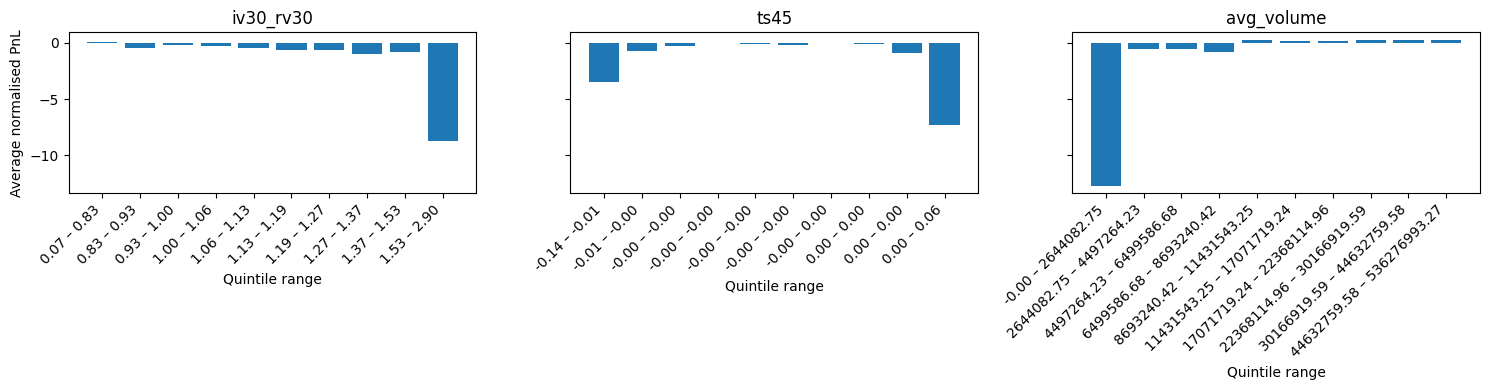

In [29]:
signals = ["iv30_rv30", "ts45", "avg_volume"]

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, sig in zip(axes, signals):
    # qcut with interval labels
    trades["q"] = pd.qcut(trades[sig], 10)

    grouped = trades.groupby("q", observed=True)["pnl_norm"].mean()

    ax.bar(
        range(len(grouped)),
        grouped.values
    )
    ax.set_title(sig)
    ax.set_xlabel("Quintile range")
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(
        [f"{interval.left:.2f} – {interval.right:.2f}" for interval in grouped.index],
        rotation=45,
        ha="right"
    )

axes[0].set_ylabel("Average normalised PnL")
plt.tight_layout()
plt.show()


## Profit with Varying Thresholds


Best (subject to min_trades filter):
  ts45 <= -0.010545  (q=0.429)
  iv30_rv30 >= 1.446931  (q=0.666)
  avg PnL = -0.7336, trades = 37


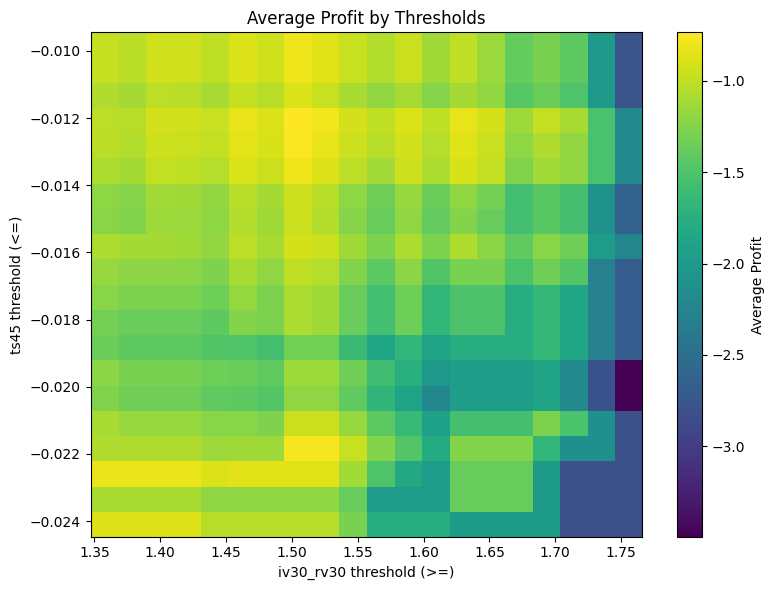

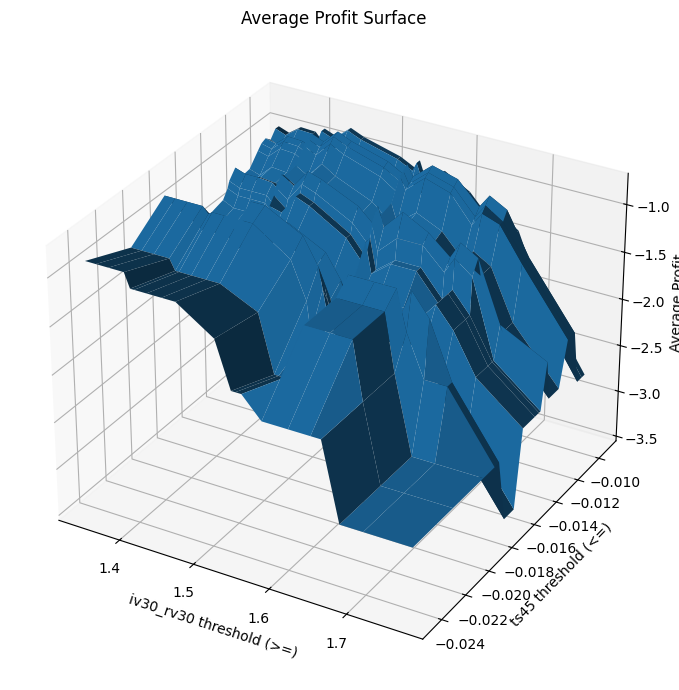

In [29]:
ts_col    = "ts45"
ratio_col = "iv30_rv30"
pnl_col   = "pnl_norm"

data = filtered_df[[ts_col, ratio_col, pnl_col]].replace([np.inf, -np.inf], np.nan).dropna() # clean data

# -----------------------
# 4) Threshold grids
#    - ts45: scan lower quantiles (more negative)
#    - ratio: scan upper quantiles (more positive)
# -----------------------
# Tweak these if you want a denser/sparser grid
q_ts  = np.linspace(0.05, 0.50, 20)   # lower quantiles for negative thresholds
q_rat = np.linspace(0.50, 0.95, 20)   # upper quantiles for positive thresholds

ts_thresholds    = np.quantile(data[ts_col], q_ts)
ratio_thresholds = np.quantile(data[ratio_col], q_rat)

# -----------------------
# 5) Compute mean PnL and trade counts per cell
# -----------------------
heat   = np.full((len(ts_thresholds), len(ratio_thresholds)), np.nan)
counts = np.zeros_like(heat, dtype=int)

for i, t_ts in enumerate(ts_thresholds):
    for j, t_rat in enumerate(ratio_thresholds):
        mask = (data[ts_col] <= t_ts) & (data[ratio_col] >= t_rat)
        sub = data.loc[mask, pnl_col]
        counts[i, j] = sub.shape[0]
        if sub.shape[0] > 0:
            heat[i, j] = sub.mean()

# -----------------------
# 6) Stability filter + best cell
# -----------------------
min_trades = max(30, int(0.001 * len(data)))  # at least 0.1% of sample or 10
best_val = np.nan
best_idx = (None, None)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if counts[i, j] >= min_trades and not np.isnan(heat[i, j]):
            if np.isnan(best_val) or heat[i, j] > best_val:
                best_val = heat[i, j]
                best_idx = (i, j)

if best_idx[0] is not None:
    i, j = best_idx
    print("\nBest (subject to min_trades filter):")
    print(f"  ts45 <= {ts_thresholds[i]:.6f}  (q={q_ts[i]:.3f})")
    print(f"  iv30_rv30 >= {ratio_thresholds[j]:.6f}  (q={q_rat[j]:.3f})")
    print(f"  avg PnL = {heat[i, j]:.4f}, trades = {counts[i, j]}")
else:
    print("\nNo cell met the minimum trade count filter.")

# -----------------------
# 7) Save tidy grid results and a ranked top list
# -----------------------
rows = []
for i, t_ts in enumerate(ts_thresholds):
    for j, t_rat in enumerate(ratio_thresholds):
        rows.append({
            "ts45_threshold": t_ts,
            "iv30_rv30_threshold": t_rat,
            "avg_profit": heat[i, j],
            "num_trades": counts[i, j],
        })
grid_df = pd.DataFrame(rows)


top = (grid_df[grid_df["num_trades"] >= min_trades]
       .sort_values("avg_profit", ascending=False)
       .head(25)
       .reset_index(drop=True))


# Heatmap of average profit
plt.figure(figsize=(8, 6))
plt.imshow(
    heat,
    aspect='auto',
    origin='lower',
    extent=[ratio_thresholds.min(), ratio_thresholds.max(),
            ts_thresholds.min(), ts_thresholds.max()]
)
plt.colorbar(label='Average Profit')
plt.xlabel('iv30_rv30 threshold (>=)')
plt.ylabel('ts45 threshold (<=)')
plt.title('Average Profit by Thresholds')
plt.tight_layout()
plt.show()

# 3D surface plot
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
# Replace NaNs with the global nanmean just for plotting continuity
Z = np.array(heat, copy=True)
Z = np.where(np.isnan(Z), np.nanmean(Z), Z)
surf = ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)
ax.set_xlabel('iv30_rv30 threshold (>=)')
ax.set_ylabel('ts45 threshold (<=)')
ax.set_zlabel('Average Profit')
ax.set_title('Average Profit Surface')
plt.tight_layout()
plt.show()